In [1]:
# %pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [2]:
training = pd.read_csv("../training_data.csv", encoding="latin1")
test = pd.read_csv("../test_data.csv", encoding="latin1")

In [3]:
training.columns

Index(['city_name', 'record_date', 'AVERAGE_SPEED_DIFF',
       'AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF',
       'AVERAGE_FREE_FLOW_TIME', 'LUMINOSITY', 'AVERAGE_TEMPERATURE',
       'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY', 'AVERAGE_WIND_SPEED',
       'AVERAGE_CLOUDINESS', 'AVERAGE_PRECIPITATION', 'AVERAGE_RAIN'],
      dtype='object')

In [4]:
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                6812 non-null   object 
 1   record_date              6812 non-null   object 
 2   AVERAGE_SPEED_DIFF       4612 non-null   object 
 3   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 4   AVERAGE_TIME_DIFF        6812 non-null   float64
 5   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 6   LUMINOSITY               6812 non-null   object 
 7   AVERAGE_TEMPERATURE      6812 non-null   float64
 8   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 9   AVERAGE_HUMIDITY         6812 non-null   float64
 10  AVERAGE_WIND_SPEED       6812 non-null   float64
 11  AVERAGE_CLOUDINESS       4130 non-null   object 
 12  AVERAGE_PRECIPITATION    6812 non-null   float64
 13  AVERAGE_RAIN             563 non-null    object 
dtypes: float64(8), object(6)

In [5]:
training.head()

,city_name,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_PRECIPITATION,AVERAGE_RAIN
0,Porto,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,LIGHT,15.0,1019.0,100.0,3.0,NaN,0.0,NaN
1,Porto,2018-08-10 14:00:00,High,41.7,48.3,87.4,LIGHT,21.0,1021.0,53.0,5.0,céu claro,0.0,NaN
2,Porto,2019-09-01 16:00:00,High,38.6,38.4,85.2,LIGHT,26.0,1014.0,61.0,4.0,NaN,0.0,NaN
3,Porto,2019-02-26 11:00:00,High,37.4,61.0,94.1,LIGHT,18.0,1025.0,48.0,4.0,céu claro,0.0,NaN
4,Porto,2019-06-06 12:00:00,Medium,41.6,50.4,77.0,LIGHT,15.0,1008.0,82.0,10.0,NaN,0.0,NaN


<Axes: >

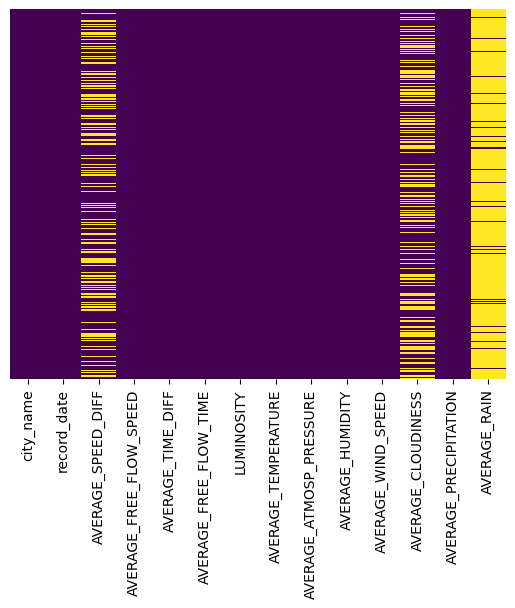

In [6]:
sns.heatmap(training.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [7]:
training.isnull().sum()

city_name                     0
record_date                   0
AVERAGE_SPEED_DIFF         2200
AVERAGE_FREE_FLOW_SPEED       0
AVERAGE_TIME_DIFF             0
AVERAGE_FREE_FLOW_TIME        0
LUMINOSITY                    0
AVERAGE_TEMPERATURE           0
AVERAGE_ATMOSP_PRESSURE       0
AVERAGE_HUMIDITY              0
AVERAGE_WIND_SPEED            0
AVERAGE_CLOUDINESS         2682
AVERAGE_PRECIPITATION         0
AVERAGE_RAIN               6249
dtype: int64

In [8]:
training.nunique()

city_name                     1
record_date                6812
AVERAGE_SPEED_DIFF            4
AVERAGE_FREE_FLOW_SPEED     225
AVERAGE_TIME_DIFF          1151
AVERAGE_FREE_FLOW_TIME      442
LUMINOSITY                    3
AVERAGE_TEMPERATURE          38
AVERAGE_ATMOSP_PRESSURE      43
AVERAGE_HUMIDITY             77
AVERAGE_WIND_SPEED           15
AVERAGE_CLOUDINESS            9
AVERAGE_PRECIPITATION         1
AVERAGE_RAIN                 13
dtype: int64

# *Data pre-processing*

In [9]:
# Dropping unique values

training.drop('city_name', axis=1, inplace=True)
test.drop('city_name', axis=1, inplace=True)

training.drop('AVERAGE_PRECIPITATION', axis=1, inplace=True)
test.drop('AVERAGE_PRECIPITATION', axis=1, inplace=True)

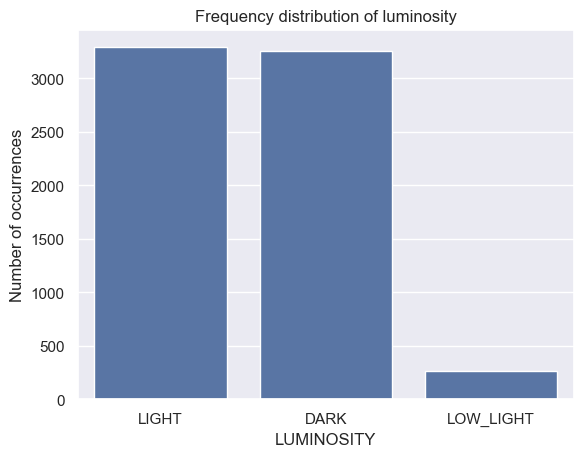

In [10]:
# Handling categorical data ... for LUMINOSITY

lum_count = training['LUMINOSITY'].value_counts()
sns.set(style='darkgrid')
sns.barplot(x=lum_count.index, y=lum_count.values)
plt.title('Frequency distribution of luminosity')
plt.ylabel('Number of occurrences', fontsize=12)
plt.xlabel('LUMINOSITY', fontsize=12)
plt.show()

In [11]:
# Using the factorising technique

training['LUMINOSITY'] = pd.factorize(training['LUMINOSITY'])[0]+1
test['LUMINOSITY'] = pd.factorize(test['LUMINOSITY'])[0]+1

In [12]:
def is_raining_func(x):
    if pd.isna(x):
        return 0
    x_str = str(x).lower()
    # Verifica se contém palavras relacionadas a chuva
    rain_keywords = ['chuva', 'rain', 'drizzle', 'shower', 'chuvisco', 'garoa']
    for keyword in rain_keywords:
        if keyword in x_str:
            return 1
    # Verifica se é um número maior que 0
    try:
        if float(x) > 0:
            return 1
    except:
        pass
    return 0

training['is_raining'] = training['AVERAGE_RAIN'].apply(is_raining_func)
test['is_raining'] = test['AVERAGE_RAIN'].apply(is_raining_func)

In [13]:
cloudiness_training = pd.get_dummies(training['AVERAGE_CLOUDINESS'], drop_first=True)
cloudiness_test = pd.get_dummies(test['AVERAGE_CLOUDINESS'], drop_first=True)
rain_training = pd.get_dummies(training['AVERAGE_RAIN'], drop_first=True)
rain_test = pd.get_dummies(test['AVERAGE_RAIN'], drop_first=True)

training.drop(['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN'], axis=1, inplace=True)
training = pd.concat([training,cloudiness_training, rain_training], axis=1)

test.drop(['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN'], axis=1, inplace=True)
test = pd.concat([test,cloudiness_test, rain_test], axis=1)

In [14]:
training.head()

,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,...,chuva de intensidade pesada,chuva de intensidade pesado,chuva forte,chuva fraca,chuva leve,chuva moderada,chuvisco e chuva fraca,chuvisco fraco,trovoada com chuva,trovoada com chuva leve
0,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,1,15.0,1019.0,100.0,3.0,...,False,False,False,False,False,False,False,False,False,False
1,2018-08-10 14:00:00,High,41.7,48.3,87.4,1,21.0,1021.0,53.0,5.0,...,False,False,False,False,False,False,False,False,False,False
2,2019-09-01 16:00:00,High,38.6,38.4,85.2,1,26.0,1014.0,61.0,4.0,...,False,False,False,False,False,False,False,False,False,False
3,2019-02-26 11:00:00,High,37.4,61.0,94.1,1,18.0,1025.0,48.0,4.0,...,False,False,False,False,False,False,False,False,False,False
4,2019-06-06 12:00:00,Medium,41.6,50.4,77.0,1,15.0,1008.0,82.0,10.0,...,False,False,False,False,False,False,False,False,False,False


In [15]:
training = training.dropna(subset=['record_date'])
training['record_date'] = pd.to_datetime(training['record_date'], format = '%Y-%m-%d %H:%M:%S', errors = 'coerce')
assert training['record_date'].isnull().sum() == 0, 'missing record date'
print(training['record_date'].head())

test = test.dropna(subset=['record_date'])
test['record_date'] = pd.to_datetime(test['record_date'], format = '%Y-%m-%d %H:%M:%S', errors = 'coerce')
assert test['record_date'].isnull().sum() == 0, 'missing record date'
print(test['record_date'].head())

0   2019-08-29 07:00:00
1   2018-08-10 14:00:00
2   2019-09-01 16:00:00
3   2019-02-26 11:00:00
4   2019-06-06 12:00:00
Name: record_date, dtype: datetime64[ns]
0   2019-02-13 23:00:00
1   2018-11-28 20:00:00
2   2018-08-14 05:00:00
3   2019-07-06 17:00:00
4   2018-10-15 06:00:00
Name: record_date, dtype: datetime64[ns]


In [16]:
training['record_date_year'] = training['record_date'].dt.year
training['record_date_month'] = training['record_date'].dt.month
training['record_date_day'] = training['record_date'].dt.day
training['record_date_hour'] = training['record_date'].dt.hour
training['record_date_minute'] = training['record_date'].dt.minute
training['record_date_second'] = training['record_date'].dt.second
training.head()

test['record_date_year'] = test['record_date'].dt.year
test['record_date_month'] = test['record_date'].dt.month
test['record_date_day'] = test['record_date'].dt.day
test['record_date_hour'] = test['record_date'].dt.hour
test['record_date_minute'] = test['record_date'].dt.minute
test['record_date_second'] = test['record_date'].dt.second
test.head()

,record_date,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,is_raining,...,chuva moderada,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour,record_date_minute,record_date_second
0,2019-02-13 23:00:00,39.2,0.0,91.0,1,8.0,1026.0,71.0,1.0,0,...,False,False,False,False,2019,2,13,23,0,0
1,2018-11-28 20:00:00,42.5,12.2,76.8,1,11.0,1020.0,93.0,4.0,0,...,False,False,False,False,2018,11,28,20,0,0
2,2018-08-14 05:00:00,45.9,0.0,86.3,1,14.0,1017.0,93.0,0.0,0,...,False,False,False,False,2018,8,14,5,0,0
3,2019-07-06 17:00:00,33.2,51.7,89.9,2,22.0,1016.0,77.0,4.0,0,...,False,False,False,False,2019,7,6,17,0,0
4,2018-10-15 06:00:00,44.0,3.5,85.5,1,12.0,1004.0,100.0,9.0,1,...,False,False,False,False,2018,10,15,6,0,0


In [17]:
training.nunique()

record_date                    6812
AVERAGE_SPEED_DIFF                4
AVERAGE_FREE_FLOW_SPEED         225
AVERAGE_TIME_DIFF              1151
AVERAGE_FREE_FLOW_TIME          442
LUMINOSITY                        3
AVERAGE_TEMPERATURE              38
AVERAGE_ATMOSP_PRESSURE          43
AVERAGE_HUMIDITY                 77
AVERAGE_WIND_SPEED               15
is_raining                        2
céu claro                         2
céu limpo                         2
céu pouco nublado                 2
nublado                           2
nuvens dispersas                  2
nuvens quebradas                  2
nuvens quebrados                  2
tempo nublado                     2
aguaceiros fracos                 2
chuva                             2
chuva de intensidade pesada       2
chuva de intensidade pesado       2
chuva forte                       2
chuva fraca                       2
chuva leve                        2
chuva moderada                    2
chuvisco e chuva fraca      

In [18]:
test.nunique()

record_date                1500
AVERAGE_FREE_FLOW_SPEED     199
AVERAGE_TIME_DIFF           610
AVERAGE_FREE_FLOW_TIME      337
LUMINOSITY                    3
AVERAGE_TEMPERATURE          32
AVERAGE_ATMOSP_PRESSURE      42
AVERAGE_HUMIDITY             70
AVERAGE_WIND_SPEED           14
is_raining                    2
céu claro                     2
céu limpo                     2
céu pouco nublado             2
nublado                       2
nuvens dispersas              2
nuvens quebradas              2
nuvens quebrados              2
tempo nublado                 2
aguaceiros fracos             2
chuva                         2
chuva fraca                   2
chuva leve                    2
chuva moderada                2
chuvisco fraco                2
trovoada com chuva            2
trovoada com chuva leve       2
record_date_year              2
record_date_month            12
record_date_day              31
record_date_hour             24
record_date_minute            1
record_d

In [19]:
training.isnull().sum()

record_date                       0
AVERAGE_SPEED_DIFF             2200
AVERAGE_FREE_FLOW_SPEED           0
AVERAGE_TIME_DIFF                 0
AVERAGE_FREE_FLOW_TIME            0
LUMINOSITY                        0
AVERAGE_TEMPERATURE               0
AVERAGE_ATMOSP_PRESSURE           0
AVERAGE_HUMIDITY                  0
AVERAGE_WIND_SPEED                0
is_raining                        0
céu claro                         0
céu limpo                         0
céu pouco nublado                 0
nublado                           0
nuvens dispersas                  0
nuvens quebradas                  0
nuvens quebrados                  0
tempo nublado                     0
aguaceiros fracos                 0
chuva                             0
chuva de intensidade pesada       0
chuva de intensidade pesado       0
chuva forte                       0
chuva fraca                       0
chuva leve                        0
chuva moderada                    0
chuvisco e chuva fraca      

In [20]:
training['is_rush_hour'] = training['record_date_hour'].apply(
    lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0
)
test['is_rush_hour'] = test['record_date_hour'].apply(
    lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0
)

In [21]:
# Dropping unique date values

training.drop('record_date_minute', axis=1, inplace=True)
training.drop('record_date_second', axis=1, inplace=True)
training.drop('record_date', axis=1, inplace=True)
#training.dropna(inplace=True)
training.head()

test.drop('record_date_minute', axis=1, inplace=True)
test.drop('record_date_second', axis=1, inplace=True)
test.drop('record_date', axis=1, inplace=True)
test.dropna(inplace=True)
test.head()

,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,is_raining,céu claro,...,chuva leve,chuva moderada,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour,is_rush_hour
0,39.2,0.0,91.0,1,8.0,1026.0,71.0,1.0,0,True,...,False,False,False,False,False,2019,2,13,23,0
1,42.5,12.2,76.8,1,11.0,1020.0,93.0,4.0,0,False,...,False,False,False,False,False,2018,11,28,20,0
2,45.9,0.0,86.3,1,14.0,1017.0,93.0,0.0,0,False,...,False,False,False,False,False,2018,8,14,5,0
3,33.2,51.7,89.9,2,22.0,1016.0,77.0,4.0,0,False,...,False,False,False,False,False,2019,7,6,17,1
4,44.0,3.5,85.5,1,12.0,1004.0,100.0,9.0,1,False,...,False,False,False,False,False,2018,10,15,6,0


In [22]:
training['critical_condition'] = (
    (training['is_rush_hour'] == 1) & 
    (training['is_raining'] == 1) & 
    (training['LUMINOSITY'] == 1)
).astype(int)

test['critical_condition'] = (
    (test['is_rush_hour'] == 1) & 
    (test['is_raining'] == 1) & 
    (test['LUMINOSITY'] == 1)
).astype(int)

print("\n=== critical_condition ===")
print(f"Training: {training['critical_condition'].sum()} casos críticos ({training['critical_condition'].mean()*100:.2f}%)")
print(f"Test: {test['critical_condition'].sum()} casos críticos ({test['critical_condition'].mean()*100:.2f}%)")

training['rush_hour_rain'] = ((training['is_rush_hour'] == 1) & (training['is_raining'] == 1)).astype(int)
test['rush_hour_rain'] = ((test['is_rush_hour'] == 1) & (test['is_raining'] == 1)).astype(int)

print(f"\n=== rush_hour_rain (menos restritivo) ===")
print(f"Training: {training['rush_hour_rain'].sum()} casos ({training['rush_hour_rain'].mean()*100:.2f}%)")
print(f"Test: {test['rush_hour_rain'].sum()} casos ({test['rush_hour_rain'].mean()*100:.2f}%)")


=== critical_condition ===
Training: 67 casos críticos (0.98%)
Test: 11 casos críticos (0.73%)

=== rush_hour_rain (menos restritivo) ===
Training: 125 casos (1.83%)
Test: 38 casos (2.53%)


In [23]:
training.head()

,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,is_raining,...,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour,is_rush_hour,critical_condition,rush_hour_rain
0,Medium,41.5,11.5,71.4,1,15.0,1019.0,100.0,3.0,0,...,False,False,False,2019,8,29,7,1,0,0
1,High,41.7,48.3,87.4,1,21.0,1021.0,53.0,5.0,0,...,False,False,False,2018,8,10,14,0,0,0
2,High,38.6,38.4,85.2,1,26.0,1014.0,61.0,4.0,0,...,False,False,False,2019,9,1,16,0,0,0
3,High,37.4,61.0,94.1,1,18.0,1025.0,48.0,4.0,0,...,False,False,False,2019,2,26,11,0,0,0
4,Medium,41.6,50.4,77.0,1,15.0,1008.0,82.0,10.0,0,...,False,False,False,2019,6,6,12,0,0,0


# *Feature Importance*

In [24]:
from sklearn.ensemble import AdaBoostClassifier

X_temp = training.drop('AVERAGE_SPEED_DIFF', axis=1)
y_temp = training['AVERAGE_SPEED_DIFF'].fillna("None")
y_temp = y_temp.map({"None": 0, "Low":1, "Medium":2, "High":3, "Very_High":4})

ada_temp = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(max_depth=3, random_state=42),
    n_estimators = 50,
    random_state = 42
)

ada_temp.fit(X_temp, y_temp)

feature_importance = ada_temp.feature_importances_
feature_names = X_temp.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending = False)

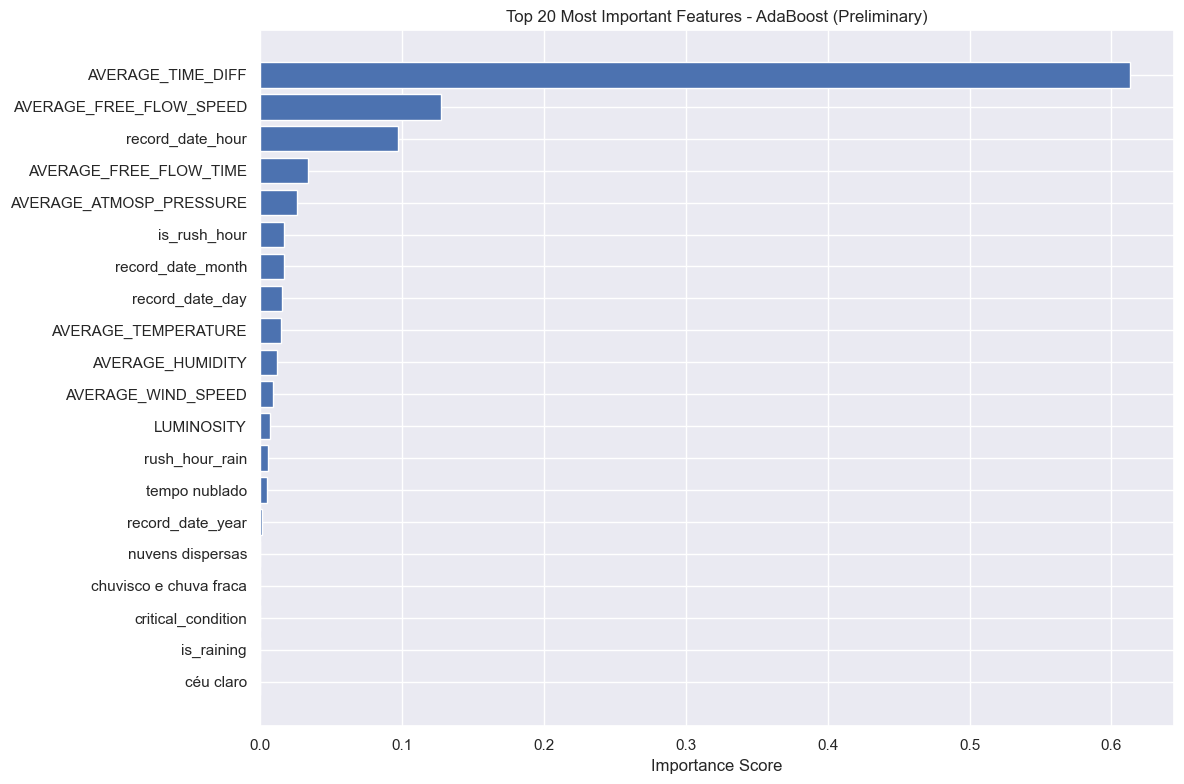

In [25]:
plt.figure(figsize=(12,8))
top_n = 20
top_features = importance_df.head(top_n)

plt.barh(range(top_n), top_features['Importance'])
plt.yticks(range(top_n), top_features['Feature'])
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Most Important Features - AdaBoost (Preliminary)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# *Feature Selection*

In [26]:
threshold = 0.01 #Features com importância > 1%
selected_features_threshold = importance_df[importance_df['Importance'] > threshold]['Feature'].tolist()

top_n_features = 20
selected_features_topn = importance_df.head(top_n_features)['Feature'].tolist()

USE_FEATURE_SELECTION = True
SELECTION_METHOD = 'threshold' # 'threshold' ou 'topn'

if USE_FEATURE_SELECTION:
    if SELECTION_METHOD == 'threshold':
        selected_features = selected_features_threshold
    else:
        selected_features = selected_features_topn

    for i, feat in enumerate(selected_features[:10],1):
        imp = importance_df[importance_df['Feature'] == feat]['Importance'].values[0]
        print(f" {i:2d}. {feat:30} {imp:.4f} ")
else:
    selected_features = feature_names.tolist()

features_to_keep = selected_features.copy()

  1. AVERAGE_TIME_DIFF              0.6135 
  2. AVERAGE_FREE_FLOW_SPEED        0.1277 
  3. record_date_hour               0.0971 
  4. AVERAGE_FREE_FLOW_TIME         0.0336 
  5. AVERAGE_ATMOSP_PRESSURE        0.0258 
  6. is_rush_hour                   0.0171 
  7. record_date_month              0.0168 
  8. record_date_day                0.0152 
  9. AVERAGE_TEMPERATURE            0.0145 
 10. AVERAGE_HUMIDITY               0.0116 


In [27]:
if USE_FEATURE_SELECTION and len(features_to_keep) < len(feature_names):
    print(f"Reduzir de {len(feature_names)} para {len(features_to_keep)} features...")
    
    training_selected = training[features_to_keep + ['AVERAGE_SPEED_DIFF']].copy()
    test_selected = test[features_to_keep].copy()
    
    print(f"Training: {training_selected.shape}")
    print(f"Test: {test_selected.shape}")
    
    # SUBSTITUIR os dataframes originais
    training = training_selected
    test = test_selected
    
    print(f"Feature Selection aplicada com sucesso!")
else:
    print(f"Sem redução de features")

Reduzir de 36 para 10 features...
Training: (6812, 11)
Test: (1500, 10)
Feature Selection aplicada com sucesso!


# *Training model*

In [28]:
# Preparar X_train e y_train
X_train_full = training.drop('AVERAGE_SPEED_DIFF', axis=1)
y_train_full = training['AVERAGE_SPEED_DIFF']

# X_test é o test completo (não tem AVERAGE_SPEED_DIFF)
X_test = test.copy()

print("Antes do alinhamento:")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")

# Adicionar colunas que existem no training mas não no test
missing_cols = set(X_train_full.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0
    print(f"Adicionada coluna '{col}' ao test")

# Remover colunas que existem no test mas não no training
extra_cols = set(X_test.columns) - set(X_train_full.columns)
if len(extra_cols) > 0:
    X_test.drop(list(extra_cols), axis=1, inplace=True)
    print(f"Removidas {len(extra_cols)} colunas extra do test")

# Reordenar colunas do test para ficarem na mesma ordem que o training
X_test = X_test[X_train_full.columns]

print("\nDepois do alinhamento:")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")
print(f"Colunas coincidem: {list(X_train_full.columns) == list(X_test.columns)}")

Antes do alinhamento:
X_train: (6812, 10)
X_test: (1500, 10)
X_train: (6812, 10)
X_test: (1500, 10)

Depois do alinhamento:
X_train: (6812, 10)
X_test: (1500, 10)
Colunas coincidem: True


In [29]:
y_train_full.fillna("None", inplace=True) # muito importante

In [30]:
y_train_full.value_counts()

AVERAGE_SPEED_DIFF
None         2200
Medium       1651
Low          1419
High         1063
Very_High     479
Name: count, dtype: int64

In [31]:
mapper = {"None": 0, "Low": 1, "Medium": 2, "High": 3, "Very_High": 4}
y_train_full = y_train_full.map(mapper)
y_train_full.value_counts()

AVERAGE_SPEED_DIFF
0    2200
2    1651
1    1419
3    1063
4     479
Name: count, dtype: int64

# *Feature Weighting*

In [32]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_full = compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(y_train_full),
    y = y_train_full
)

weight_dict_full = dict(enumerate(class_weights_full))
sample_weights_full = np.array([weight_dict_full[y] for y in y_train_full])

print("Pesos por classe:")
for class_id, weight in weight_dict_full.items():
    class_name = {0: "None", 1: "Low", 2: "Medium", 3: "High", 4: "Very_High"}[class_id]
    count = (y_train_full == class_id).sum()
    print(f" {class_name:12} - {count:4d} amostras | Peso: {weight:.3f}")

Pesos por classe:
 None         - 2200 amostras | Peso: 0.619
 Low          - 1419 amostras | Peso: 0.960
 Medium       - 1651 amostras | Peso: 0.825
 High         - 1063 amostras | Peso: 1.282
 Very_High    -  479 amostras | Peso: 2.844


# *GridSearchCV*

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel

# Dividir dados para validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full,
    test_size=0.3,      # 30% para validação
    random_state=42,
    stratify=y_train_full  # Mantém proporções das classes
)

sample_weights_train = sample_weights_full[X_train.index]
sample_weights_val = sample_weights_full[X_val.index]

print(f"Pesos Treino: {len(sample_weights_train)}")
print(f"Pesos Validação: {len(sample_weights_val)}")

print(f"\nTreino: {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Test: {X_test.shape}")

Pesos Treino: 4768
Pesos Validação: 2044

Treino: (4768, 10)
Validação: (2044, 10)
Test: (1500, 10)


In [34]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Base estimator
base_dt = DecisionTreeClassifier(random_state=42)

# AdaBoost
ada = AdaBoostClassifier(estimator=base_dt, random_state=42)

# Grelha de parâmetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0],
    'estimator__max_depth': [1, 2, 3],
    'estimator__min_samples_split': [2, 5, 10]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Treinar GridSearch
grid_search.fit(X_train, y_train, sample_weight=sample_weights_train)

# Mostrar melhores parâmetros
print(f"\nMelhores parâmetros encontrados:")
print(grid_search.best_params_)
print(f"\nMelhor score (CV): {grid_search.best_score_:.4f}")

# Melhor modelo
best_ada = grid_search.best_estimator_


Fitting 5 folds for each of 81 candidates, totalling 405 fits

Melhores parâmetros encontrados:
{'estimator__max_depth': 3, 'estimator__min_samples_split': 5, 'learning_rate': 0.1, 'n_estimators': 100}

Melhor score (CV): 0.7826


# *Feature Importance do Modelo Final*

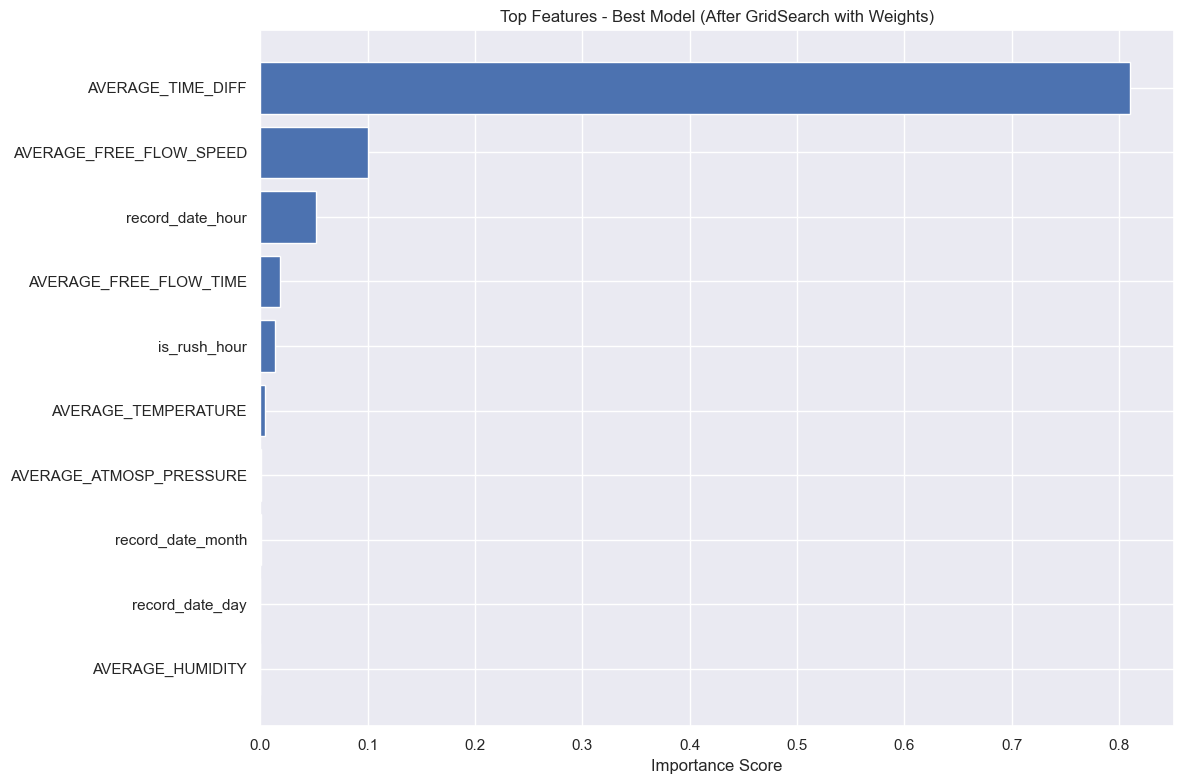

In [35]:
feature_importance_final = best_ada.feature_importances_
feature_names_final = X_train.columns

importance_df_final = pd.DataFrame({
    'Feature': feature_names_final,
    'Importance': feature_importance_final
}).sort_values('Importance', ascending = False)

# Comparação com análise preliminar (se possível)
if len(feature_names_final) == len(feature_names):
    print("\nComparação com análise preliminar:")
    print("-" * 60)
    for feat in importance_df_final.head(5)['Feature'].tolist():
        imp_final = importance_df_final[importance_df_final['Feature'] == feat]['Importance'].values[0]
        imp_prelim = importance_df[importance_df['Feature'] == feat]['Importance'].values[0]
        diff = imp_final - imp_prelim
        print(f"  {feat:30} Prelim: {imp_prelim:.4f} → Final: {imp_final:.4f} ({diff:+.4f})")

# Visualização final
plt.figure(figsize=(12, 8))
top_n = min(20, len(feature_names_final))
top_features_final = importance_df_final.head(top_n)

plt.barh(range(top_n), top_features_final['Importance'])
plt.yticks(range(top_n), top_features_final['Feature'])
plt.xlabel('Importance Score')
plt.title('Top Features - Best Model (After GridSearch with Weights)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [36]:
# Avaliar no conjunto de treino
train_predictions = best_ada.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)
print(f"\nAccuracy no TREINO: {train_accuracy * 100:.2f}%")

# Avaliar no conjunto de validação
val_predictions = best_ada.predict(X_val)
val_accuracy = accuracy_score(y_val, val_predictions)
print(f"Accuracy na VALIDAÇÃO: {val_accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, val_predictions, zero_division=0))  # zero_division para evitar warnings

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_predictions))



Accuracy no TREINO: 78.02%
Accuracy na VALIDAÇÃO: 77.35%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.83      0.88       660
           1       0.60      0.81      0.69       426
           2       0.79      0.65      0.71       495
           3       0.76      0.75      0.75       319
           4       0.81      0.87      0.84       144

    accuracy                           0.77      2044
   macro avg       0.78      0.78      0.77      2044
weighted avg       0.79      0.77      0.78      2044


Confusion Matrix:
[[550 109   1   0   0]
 [ 45 346  34   1   0]
 [  2 114 322  56   1]
 [  0   3  49 238  29]
 [  0   0   0  19 125]]


# *Boosting*

In [37]:
# Extrair melhores parâmetros
best_params = grid_search.best_params_

# Parâmetros do AdaBoost
ada_params = {
    'n_estimators': best_params['n_estimators'],
    'learning_rate': best_params['learning_rate'],
    'random_state': 42
}

# Parâmetros do estimator interno (DecisionTree)
estimator_params = {
    'max_depth': best_params['estimator__max_depth'],
    'min_samples_split': best_params['estimator__min_samples_split'],
    'random_state': 42
}

# Criar AdaBoost final com os melhores parâmetros
ada_final = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(**estimator_params),
    **ada_params
)

# Treinar com todo o dataset
ada_final.fit(X_train_full, y_train_full, sample_weight=sample_weights_full)

# Fazer previsões no test
test_predictions = ada_final.predict(X_test)

In [38]:
mapper = {0: "None", 1: "Low", 2: "Medium", 3: "High", 4: "Very_High"}
test_predictions = pd.Series(test_predictions).map(mapper)

In [39]:
output = pd.DataFrame({
    'RowId': range(1, len(test_predictions) + 1),
    'Speed_Diff': test_predictions
})
output.to_csv('../predictions/Boosting+GridSearch_V2.csv', index=False)
print("\nPrevisões salvas em 'Boosting+GridSearch_V2.csv'")


Previsões salvas em 'Boosting+GridSearch_V2.csv'


In [40]:
results_df = pd.DataFrame(grid_search.cv_results_)
print("\nTop 5 combinações de parâmetros:")
print(results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
      .sort_values('rank_test_score')
      .head())


Top 5 combinações de parâmetros:
                                               params  mean_test_score  \
64  {'estimator__max_depth': 3, 'estimator__min_sa...         0.782596   
55  {'estimator__max_depth': 3, 'estimator__min_sa...         0.782499   
73  {'estimator__max_depth': 3, 'estimator__min_sa...         0.782371   
56  {'estimator__max_depth': 3, 'estimator__min_sa...         0.779773   
65  {'estimator__max_depth': 3, 'estimator__min_sa...         0.777131   

    std_test_score  rank_test_score  
64        0.018926                1  
55        0.018907                2  
73        0.018550                3  
56        0.016863                4  
65        0.018367                5  
